In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'xgboost'

In [4]:
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [2]:
import sys
!{sys.executable} -m pip install xgboost

^C


In [3]:
!pip install xgboost==1.7.6


^C


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('../data/processed/features.csv')

print("Shape:", df.shape)
print("Churn rate:", round(df['Churn'].mean() * 100, 2), "%")

Shape: (7043, 36)
Churn rate: 26.54 %


In [7]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
print("Features         :", X_train.shape[1])

Training samples : 5634
Testing samples  : 1409
Features         : 35


In [8]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1                  # uses all CPU cores
)

model.fit(X_train, y_train)

print("Model trained! ✅")

Model trained! ✅


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 45)
print("         MODEL EVALUATION REPORT")
print("=" * 45)
print(classification_report(y_test, y_pred, 
      target_names=['Retained', 'Churned']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")

         MODEL EVALUATION REPORT
              precision    recall  f1-score   support

    Retained       0.89      0.77      0.83      1035
     Churned       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC Score : 0.8428


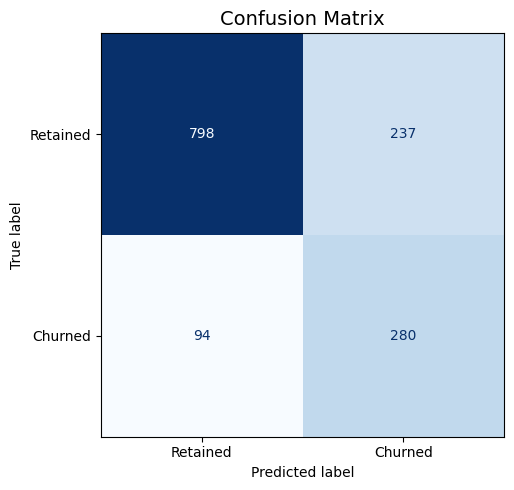

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

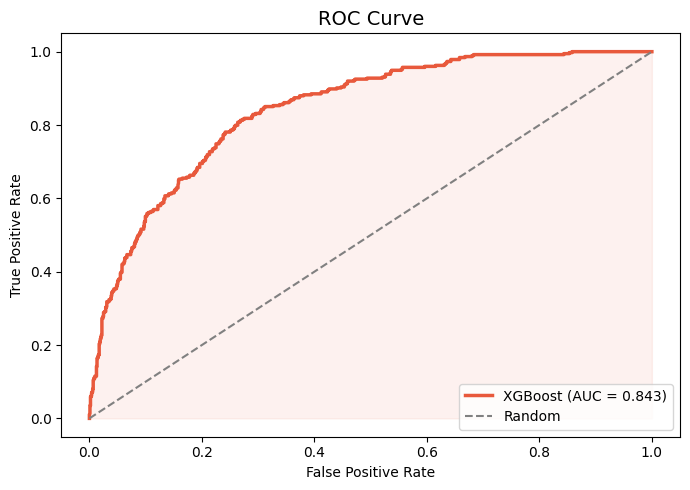

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#E8593C', lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E8593C')

ax.set_title('ROC Curve', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

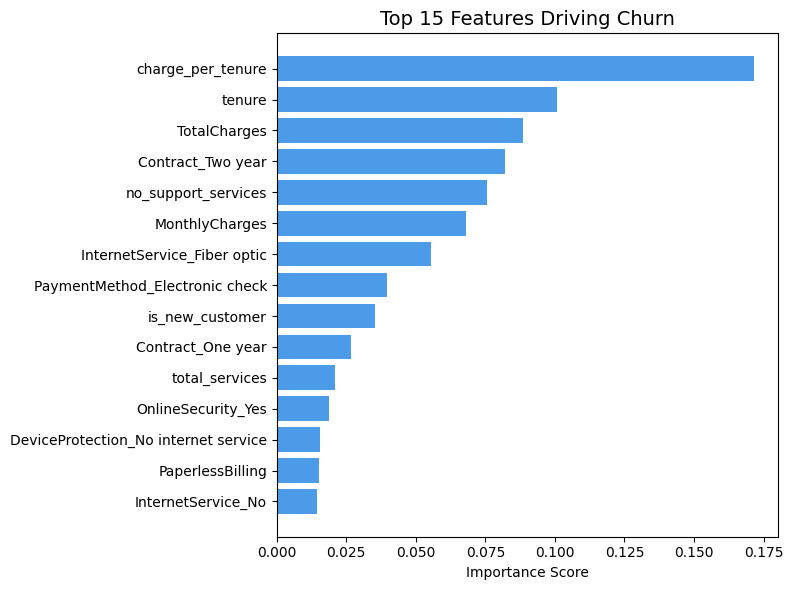

Feature importance saved!


In [12]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importance['feature'], importance['importance'], 
               color='#4C9BE8', edgecolor='none')

ax.set_title('Top 15 Features Driving Churn', fontsize=14)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

# Save feature importance as JSON
importance.to_json('../models/feature_importance.json', orient='records', indent=2)
print("Feature importance saved!")

In [13]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print("=" * 40)
print("     5-FOLD CROSS VALIDATION")
print("=" * 40)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean AUC : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")

     5-FOLD CROSS VALIDATION
  Fold 1: 0.8589
  Fold 2: 0.8582
  Fold 3: 0.8263
  Fold 4: 0.8365
  Fold 5: 0.8411

  Mean AUC : 0.8442
  Std Dev  : 0.0127


In [14]:
pickle.dump(model, open('../models/churn_model_v1.pkl', 'wb'))

print("Model saved to models/churn_model_v1.pkl ✅")

loaded_model = pickle.load(open('../models/churn_model_v1.pkl', 'rb'))
test_pred = loaded_model.predict(X_test[:5])
print("\nLoad test predictions:", test_pred)
print("Actual values        :", y_test[:5].values)

Model saved to models/churn_model_v1.pkl ✅

Load test predictions: [0 1 0 0 0]
Actual values        : [0 0 0 0 0]
